In [1]:
import pandas as pd

#Load the COVID dataset
df = pd.read_csv('owid-covid-data.csv')

#Check size
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (429435, 67)

First 5 rows:


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [2]:
#Filter only India data
india = df[df['location'] == 'India'].copy()

#Check India data size
print("India data shape:", india.shape)
print("\nDate range:")
print("Start:", india['date'].min())
print("End:", india['date'].max())

#Show first 5 row
india.head()

India data shape: (1682, 67)

Date range:
Start: 2020-01-05
End: 2024-08-12


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
173549,IND,Asia,India,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,20.6,59.55,0.53,69.66,0.64,1417173120,NaN,NaN,NaN,NaN
173550,IND,Asia,India,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,20.6,59.55,0.53,69.66,0.64,1417173120,NaN,NaN,NaN,NaN
173551,IND,Asia,India,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,20.6,59.55,0.53,69.66,0.64,1417173120,NaN,NaN,NaN,NaN
173552,IND,Asia,India,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,20.6,59.55,0.53,69.66,0.64,1417173120,NaN,NaN,NaN,NaN
173553,IND,Asia,India,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,20.6,59.55,0.53,69.66,0.64,1417173120,NaN,NaN,NaN,NaN


In [3]:
#Check missing values
print("Missing values in key columns:")
print(india[['date','total_cases','new_cases','total_deaths','new_deaths']].isnull().sum())

Missing values in key columns:
date            0
total_cases     8
new_cases       8
total_deaths    8
new_deaths      8
dtype: int64


In [4]:
#Convert date to proper date formate
india ['date'] = pd.to_datetime(india['date'])

#Extract year and month
india['year'] = india['date'].dt.year
india['month'] = india['date'].dt.month
india['month_name'] = india['date'].dt.strftime('%b')

print("Date column fixed!")
print(india[['date','year','month','month_name']].head())

Date column fixed!
             date  year  month month_name
173549 2020-01-05  2020      1        Jan
173550 2020-01-06  2020      1        Jan
173551 2020-01-07  2020      1        Jan
173552 2020-01-08  2020      1        Jan
173553 2020-01-09  2020      1        Jan


In [5]:
#Fill missing values with 0
india['new_cased'] = india['new_cases'].fillna(0)
india['new_deaths'] = india['new_deaths'].fillna(0)
india['total_cases'] = india['total_cases'].fillna(0)
india['total_deaths'] = india['total_deaths'].fillna(0)

print("Missing values fixed!")
print(india[['total_cases','new_cases','total_deaths','new_deaths']].isnull().sum())

Missing values fixed!
total_cases     0
new_cases       8
total_deaths    0
new_deaths      0
dtype: int64


In [6]:
#Basic statistics of India COVID data
print("India COVID-19 Key Statistics:")
print(f"Total Cases:  {india['total_cases'].max():,.0f}")
print(f"Total Deaths: {india['total_deaths'].max():,.0f}")
print(f"Peak New Cases in a day: {india['new_cases'].max():,.0f}")
print(f"peak New Deaths in a day: {india['new_deaths'].max():,.0f}")

India COVID-19 Key Statistics:
Total Cases:  45,041,748
Total Deaths: 533,623
Peak New Cases in a day: 2,738,957
peak New Deaths in a day: 28,982


In [7]:
#Save clean India data
india.to_csv('india_covid_clean.csv', index=False)
print("Clean data saved!")
print("Shape:", india.shape)

Clean data saved!
Shape: (1682, 71)


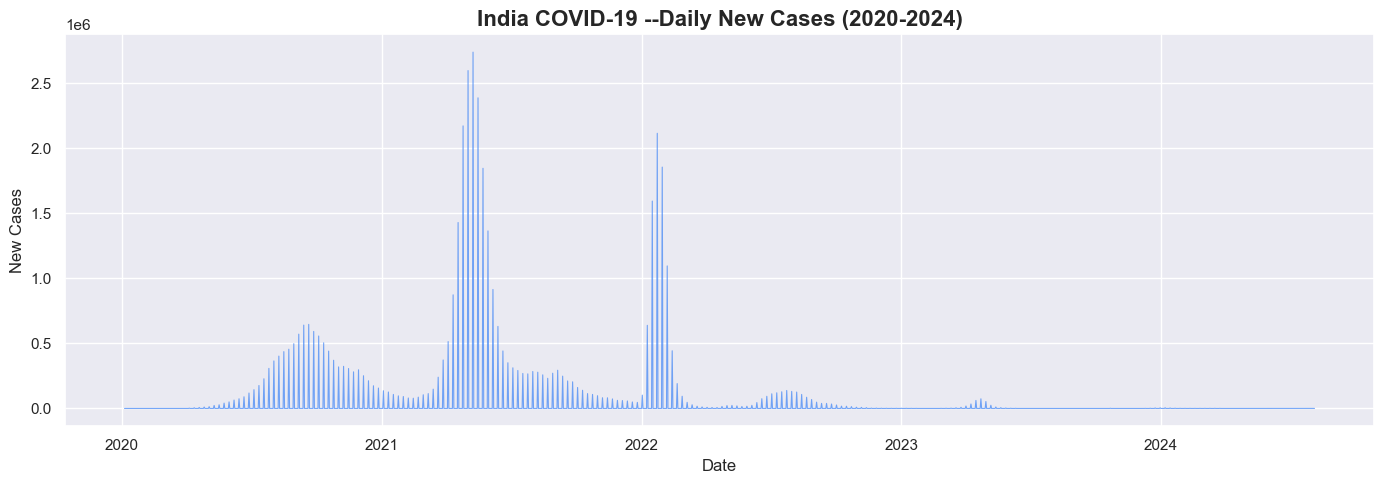

Chart 1 done!


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14,5)

#Chart 1 --Daily New Cases
plt.figure(figsize = (14,5))
plt.plot(india['date'], india['new_cases'],color='#3b82f6', linewidth=0.8, alpha=0.7)
plt.title('India COVID-19 --Daily New Cases (2020-2024)', fontsize=16, fontweight='bold')

plt.xlabel('Date', fontsize=12)
plt.ylabel('New Cases', fontsize=12)
plt.tight_layout()
plt.savefig('chart1_daily_cases.png')
plt.show()
print("Chart 1 done!")


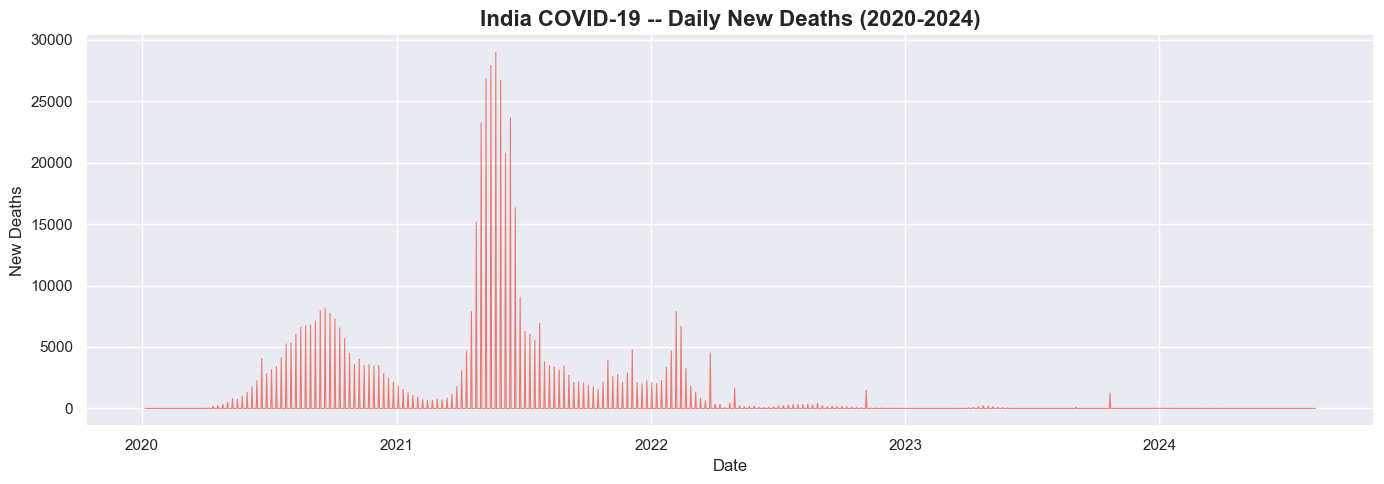

Chart 2 done!


In [9]:
#Chart 2 -- Daily New Deaths
plt.figure(figsize=(14,5))
plt.plot(india['date'],india['new_deaths'], color='#e74c3c', linewidth=0.8, alpha=0.7)
plt.title('India COVID-19 -- Daily New Deaths (2020-2024)', fontsize=16, fontweight='bold')

plt.xlabel('Date', fontsize=12)
plt.ylabel('New Deaths', fontsize=12)
plt.tight_layout()
plt.savefig('chart2_daily_deaths.png')
plt.show()
print("Chart 2 done!")

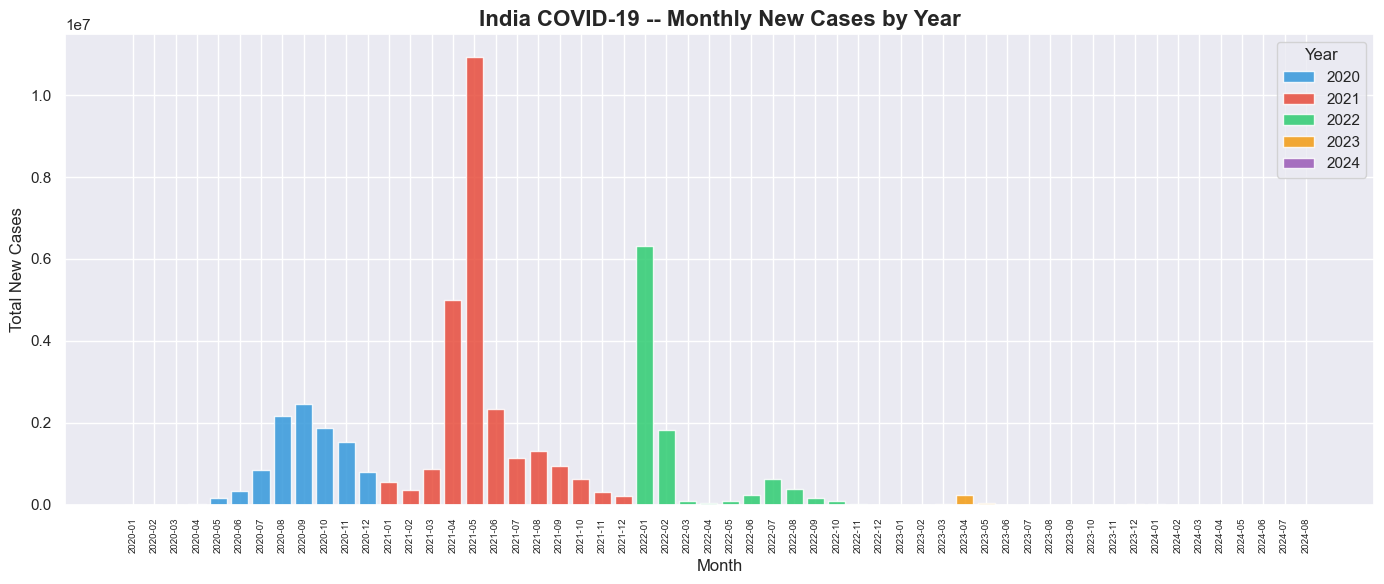

Chart 3 done!


In [10]:
#Chart 3 -- Monthly Total Cases by year 
monthly =india.groupby(['year','month'])['new_cases'].sum().reset_index()

plt.figure(figsize=(14, 6))
colors = {2020:'#3498db', 2021:'#e74c3c', 2022:'#2ecc71', 2023:'#f39c12', 2024:'#9b59b6'}

for year in monthly['year'].unique():
    data = monthly[monthly['year']==year]
    plt.bar([f"{year}-{str(m).zfill(2)}" for m in data['month']],
            data['new_cases'],
            color=colors.get(year,'gray'),
            label=str(year), alpha=0.85)

plt.title('India COVID-19 -- Monthly New Cases by Year',
          fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total New Cases', fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.legend(title='Year')
plt.tight_layout()
plt.savefig('chart3_monthly_cases.png')
plt.show()
print("Chart 3 done!")

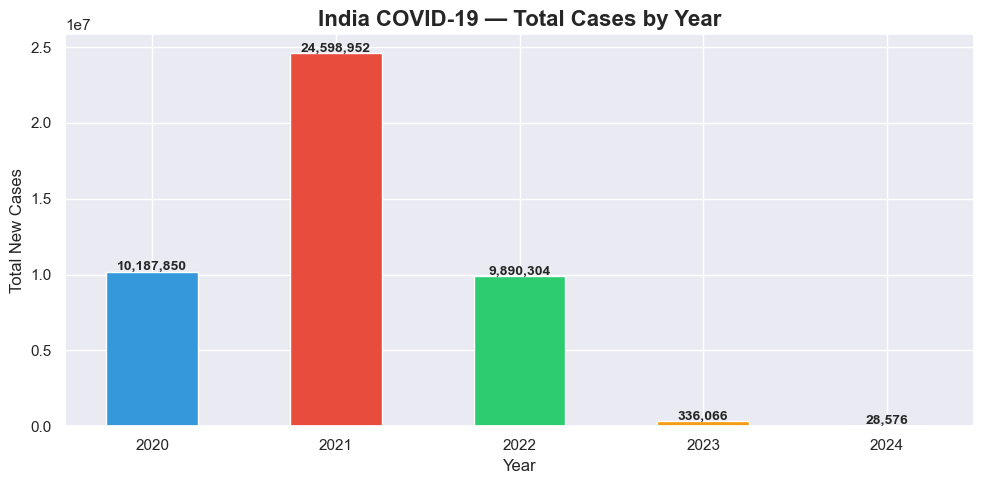

Chart 4 done!


In [12]:
# Chart 4 — Yearly Total Cases
yearly = india.groupby('year')['new_cases'].sum().reset_index()

plt.figure(figsize=(10, 5))
bars = plt.bar(yearly['year'].astype(str),
               yearly['new_cases'],
               color=['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6'],
               width=0.5, edgecolor='white')

for bar, val in zip(bars, yearly['new_cases']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100000,
             f'{val:,.0f}', ha='center',
             fontsize=10, fontweight='bold')

plt.title('India COVID-19 — Total Cases by Year',
          fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total New Cases', fontsize=12)
plt.tight_layout()
plt.savefig('chart4_yearly_cases.png')
plt.show()
print("Chart 4 done!")

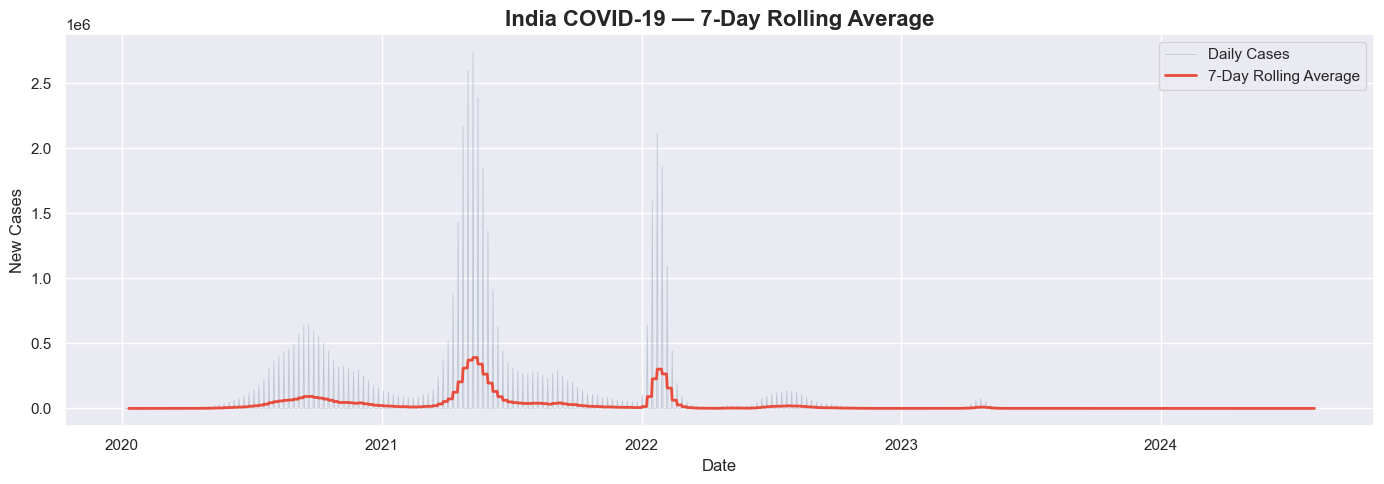

Chart 5 done!


In [13]:
# Chart 5 — 7-Day Rolling Average
india['rolling_avg'] = india['new_cases'].rolling(window=7).mean()

plt.figure(figsize=(14, 5))
plt.plot(india['date'], india['new_cases'],
         color='#94a3b8', linewidth=0.6,
         alpha=0.5, label='Daily Cases')
plt.plot(india['date'], india['rolling_avg'],
         color='#e74c3c', linewidth=2,
         label='7-Day Rolling Average')

plt.title('India COVID-19 — 7-Day Rolling Average',
          fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('New Cases', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('chart5_rolling_average.png')
plt.show()
print("Chart 5 done!")

In [14]:
print("""
==========================================
   INDIA COVID-19 ANALYSIS -- INSIGHTS
==========================================

1. WORST YEAR:
   - 2021 was deadliest with 2.46 Crore cases
   - Delta variant caused massive 2nd wave

2. PEAK DAY:
   - Highest single day: 27,38,957 cases
   - Highest single day deaths: 28,982

3. WAVE PATTERN:
   - Wave 1: Mid 2020 (Alpha variant)
   - Wave 2: Mid 2021 (Delta — most deadly)
   - Wave 3: Jan 2022 (Omicron — fast spread)

4. RECOVERY:
   - Cases dropped 99% from 2021 to 2023
   - 2024 shows near zero cases

5. TOTAL IMPACT:
   - Total Cases: 4.5 Crore (45 Million)
   - Total Deaths: 5,33,623

==========================================
CONCLUSION: India successfully controlled
COVID-19 by end of 2022 through vaccines
and public health measures!
==========================================
""")


   INDIA COVID-19 ANALYSIS -- INSIGHTS

1. WORST YEAR:
   - 2021 was deadliest with 2.46 Crore cases
   - Delta variant caused massive 2nd wave

2. PEAK DAY:
   - Highest single day: 27,38,957 cases
   - Highest single day deaths: 28,982

3. WAVE PATTERN:
   - Wave 1: Mid 2020 (Alpha variant)
   - Wave 2: Mid 2021 (Delta — most deadly)
   - Wave 3: Jan 2022 (Omicron — fast spread)

4. RECOVERY:
   - Cases dropped 99% from 2021 to 2023
   - 2024 shows near zero cases

5. TOTAL IMPACT:
   - Total Cases: 4.5 Crore (45 Million)
   - Total Deaths: 5,33,623

CONCLUSION: India successfully controlled
COVID-19 by end of 2022 through vaccines
and public health measures!

